In [1]:
import os
from os.path import expanduser
home = expanduser("~/")

import sys
# sys.path.insert(0, '/global/u2/x/xshuang/gigalens-xh-dev/src')

# import sys
conda_env = sys.path[1]
del sys.path[1]

import os
# sys.path.append(f'{os.environ['HOME']}/gigalens_personal/gigalens/src')
sys.path.append(home+'/gigalens'+'/src')
sys.path.append(conda_env)
sys.path.append(home+'/GIGALens-Code/')
print(sys.path)



srcdir = os.path.join(home, "gigalens/src/")


['', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '/usr/local/lib/python3.12/dist-packages', '__editable__.flax-0.10.6.finder.__path_hook__', '__editable__.jax_cuda12_pjrt-0.6.2.dev20250607.finder.__path_hook__', '__editable__.jax_cuda12_plugin-0.6.2.dev20250607.finder.__path_hook__', '__editable__.nsys_jax-0.1.dev1163+g4a8f06a.finder.__path_hook__', '/opt/pip/src', '/usr/lib/python3/dist-packages', '/global/homes/l/linusu//gigalens/src', '/global/homes/l/linusu/.conda/envs/gigalens_multinode_env/lib/python3.12/site-packages', '/global/homes/l/linusu//GIGALens-Code/']


In [4]:
import tensorflow_probability.substrates.jax as tfp

from gigalens.jax.inference import ModellingSequence
from gigalens.jax.model import ForwardProbModel, BackwardProbModel
from gigalens.model import PhysicalModel
from gigalens.jax.simulator import LensSimulator
from gigalens.simulator import SimulatorConfig
from gigalens.jax.profiles.light import sersic
from gigalens.jax.profiles.mass import epl, shear, tnfw

import jax
from jax import random
import numpy as np
import optax
from jax import numpy as jnp
from matplotlib import pyplot as plt
import optax
import corner
import yaml
import pickle
from helpers import *
import blackjax
import importlib
from mclmc_alt import MCLMC
tfd = tfp.distributions

In [5]:

import gigalens
importlib.reload(gigalens)
from gigalens.jax.profiles.mass import tnfw_ellipse
import lenstronomy
from lenstronomy.Data.pixel_grid import PixelGrid
import functools
from typing import List, Dict

import jax
import jax.numpy as jnp
import numpy as np
from jax import jit
from jax import lax
from lenstronomy.Util.kernel_util import subgrid_kernel
from objax.constants import ConvPadding
from objax.functional import average_pool_2d
from gigalens.jax.simulator import LensSimulator
import gigalens.model
import gigalens.simulator
from gigalens.jax.profiles.light import shapelets

In [11]:
save_dir = os.path.join(home, "GIGALens-Code/alternate_inference/vela_sim_systems/")

In [12]:
#* Load all outside data
import numpy as np, json
source_plane_dir = os.path.join(save_dir, "vela10_cam00_a0.500_f814w/")
# source_img_nJy = np.load(os.path.join(source_plane_dir, "source_image.npy"))
psf = np.load(os.path.join(source_plane_dir, "psf.npy"))
with open(os.path.join(source_plane_dir, "metadata.json")) as f:
    meta = json.load(f)


source_img_pixel_scale = meta['source_pixel_scale_arcsec']
delta_pix = meta['instrument_pixel_scale_arcsec']
num_pix = 200

sim_config = SimulatorConfig(delta_pix=delta_pix, num_pix=num_pix, supersample=1, kernel=psf)

observed_img = jnp.load(os.path.join(save_dir, "src_img.npy"))

with open(os.path.join(save_dir, "true_params"), 'rb') as file_handle:
    true_params = pickle.load(file_handle)

background_rms = 0.002
exp_time = 2000

In [8]:
class NoLens(gigalens.profile.MassProfile):
    _name = "NoLens"
    _params = ["a"]

    def __init__(self):
        super().__init__()

    @functools.partial(jit, static_argnums=(0,))
    def deriv(self, x, y, a):
        return jnp.zeros_like(x), jnp.zeros_like(y)

In [9]:
# lens_prior = tfd.JointDistributionSequential([tfd.JointDistributionNamed(dict(a=tfd.Deterministic(loc=1.)))])
# lens_light_prior = tfd.JointDistributionSequential([tfd.JointDistributionNamed(dict(a=tfd.Deterministic(loc=1.)))])

lens_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                a=tfd.LogNormal(jnp.log(0.1), 0.15),
            )
        ),
    ]
)

source_light_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                beta=tfd.LogNormal(jnp.log(0.1), 0.15),
                center_x=tfd.Normal(0, 0.1),
                center_y=tfd.Normal(0, 0.1),
                # **amp_prior
            )
        ),
    ]
)


prior_with_halo = tfd.JointDistributionSequential(
    [lens_prior, source_light_prior]
)
chisqs = []
residuals = []
best_z = []
predicted = []
coeffs = []
n_max_arr = list(range(10, 11))
for n_max in n_max_arr:
    amp_prior = {key: tfd.Normal(0,500/float(jnp.sqrt(i+1))) for i, key in enumerate(shapelets.Shapelets(n_max)._amp_names)}

    
    phys_model_halo = PhysicalModel([NoLens()], [], [shapelets.Shapelets(n_max=n_max, use_lstsq=True, interpolate=True)])
    lens_sim_halo = LensSimulator(phys_model_halo, sim_config, bs=1)
        
    prob_model_halo = BackwardProbModel(prior_with_halo, observed_img, background_rms=background_rms, exp_time=exp_time)
    model_seq_halo = ModellingSequence(phys_model_halo, prob_model_halo, sim_config)

    pipelinecfg = PipelineConfig(steps=["MAP"],map_kwargs={"num_steps":100, "n_samples":50})
    results_halo = run_pipeline(model_seq_halo, pipelinecfg)

    map_x = prob_model_halo.bij.forward(list(results_halo["MAP"].best_z.T))

    predicted_img, coeffs = lens_sim_halo.lstsq_simulate(map_x, prob_model_halo.observed_image,prob_model_halo.err_map)
    
    def get_noise_image(image, background_rms, exp_time):
        return jnp.sqrt(background_rms ** 2 + jnp.clip(image, 0, np.inf) / exp_time)
    noise_map = get_noise_image(predicted_img, background_rms, exp_time)
    
    # img_mask = predicted_img>1e-6
    # noise_map.at[img_mask].set(jnp.inf)
    
    residual = (observed_img - predicted_img)/noise_map
    
    chisq = np.sum(np.square(residual))
    dof = observed_img.shape[0]*observed_img.shape[1]-3-len(amp_prior) #! Change if number of params changes
    red_chisq = chisq/(dof)#-jnp.sum(img_mask))

    chisqs.append(red_chisq)
    residuals.append(residual)
    best_z.append(results_halo["MAP"].best_z)
    predicted.append(predicted_img)


Starting MAP


2026-03-31 15:55:37.189063: E external/xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng46{k2=5,k5=3,k14=4} for conv %cudnn-conv = (f32[792,1,200,200]{3,2,1,0}, u8[0]{0}) custom-call(%bitcast.11, %constant.1366), window={size=25x25 pad=12_12x12_12}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", metadata={op_name="jit(run_map)/jit(main)/jit(shmap_body)/while/body/map_one_step/loss_and_grad/jit(loss)/jvp(map_loss)/jit(log_prob)/backward_prob_model/lstsq_simulate/jit(lstsq_simulate)/lstsq_simulate/conv_pool/conv_general_dilated" source_file="/global/homes/l/linusu//gigalens/src/gigalens/jax/simulator.py" source_line=49}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-03-31 15:55:39.876430: E external/xla/xla/service/slow_operation

Final Chi-squared: 0.88786


In [14]:
map_x

[[{'a': Array([0.10158376], dtype=float32)}],
 [{'center_y': Array([-0.1304164], dtype=float32),
   'center_x': Array([-0.0065171], dtype=float32),
   'beta': Array([0.1815874], dtype=float32)}]]

In [13]:

jnp.save(os.path.join(save_dir, "shapelets_nmax10_coeffs.npy"), coeffs)

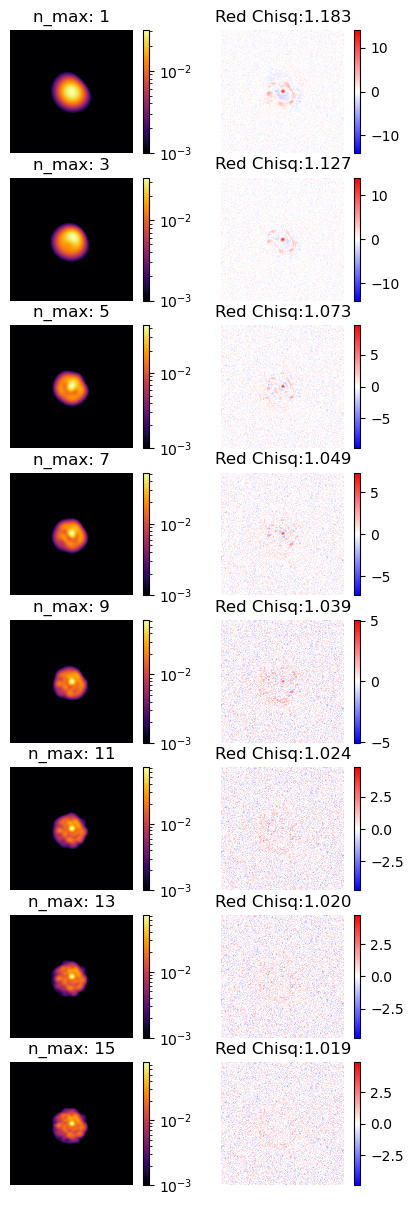

In [35]:
# fig, axs = plt.subplots(8, 2)
# fig.set_size_inches(5, 15)
# for n_max in range(1, 17, 2):
#     i = n_max//2
#     # axs[i][1].imshow(predicted[n_max])
#     plot_image(fig, axs[i][0], predicted[n_max-1], title=f"n_max: {n_max}", log_vmin=1e-3)
#     plot_image(fig, axs[i][1], residuals[n_max-1], title=f"Red Chisq:{chisqs[n_max-1]:.3f}", residual=True)
    

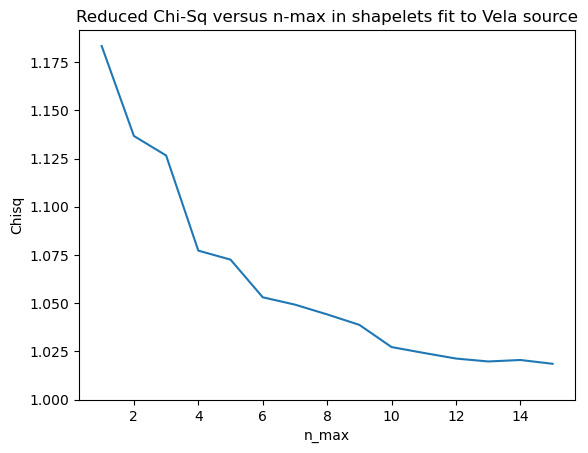

In [46]:

# num_components = [len(list(enumerate(shapelets.Shapelets(n_max)._amp_names))) for n_max in n_max_arr]

ax1 = plt.gca()
# ax2 = ax1.twiny()
ax1.plot(n_max_arr, np.array(chisqs))
# ax2.plot(num_components, np.array(chisqs))
# plt.yscale('log')
plt.ylim(bottom=1)
plt.title('Reduced Chi-Sq versus n-max in shapelets fit to Vela source')
plt.xlabel('n_max')
plt.ylabel('Chisq')
plt.show()

40757.668
1.0213418


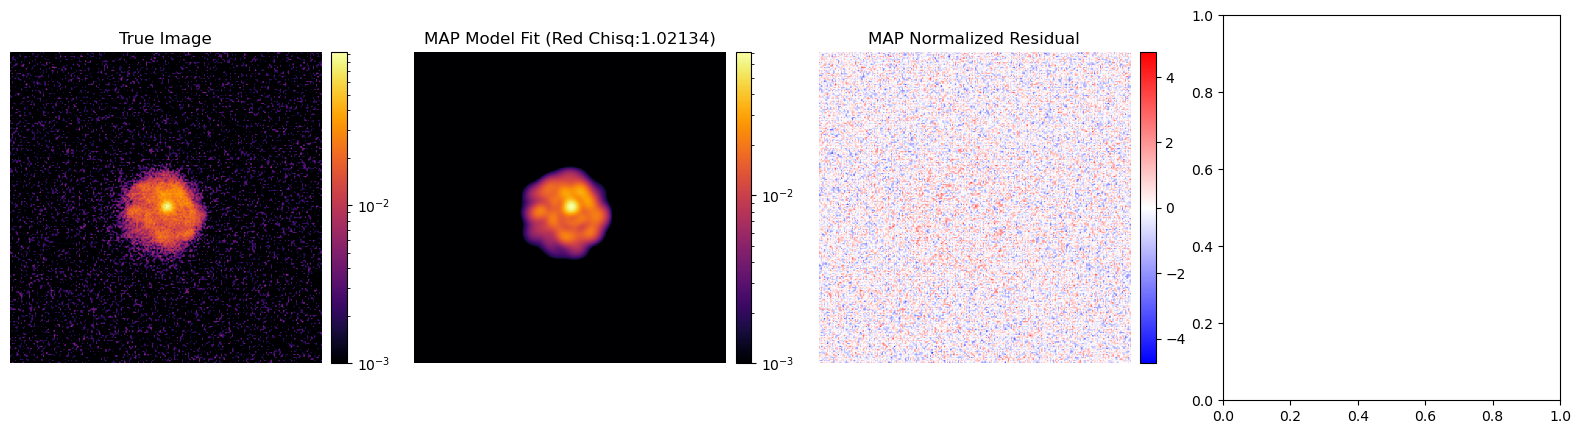

In [10]:

fig, axs = plt.subplots(1,4)
fig.set_size_inches(20,5)

# halo_median = jnp.median(mclmc_samples_halo, axis=(0,1))
# med_x_halo = prob_model_halo.bij.forward(list(halo_median.T))
map_x = prob_model_halo.bij.forward(list(results_halo["MAP"].best_z.T))

predicted_img = lens_sim_halo.lstsq_simulate(map_x, prob_model_halo.observed_image,prob_model_halo.err_map)[0]

def get_noise_image(image, background_rms, exp_time):
    return jnp.sqrt(background_rms ** 2 + jnp.clip(image, 0, np.inf) / exp_time)
noise_map = get_noise_image(predicted_img, background_rms, exp_time)

# img_mask = predicted_img>1e-6
# noise_map.at[img_mask].set(jnp.inf)

residual = (observed_img - predicted_img)/noise_map

chisq = np.sum(np.square(residual))
dof = observed_img.shape[0]*observed_img.shape[1]-3-len(amp_prior) #! Change if number of params changes
red_chisq = chisq/(dof)#-jnp.sum(img_mask))
print(chisq)
print(red_chisq)

#! Do I want to do sqrt curve cmap for the images?

extent =None
plot_image(fig, axs[0], observed_img, extent=extent,
           title=f"True Image", log_vmin=1e-3)
plot_image(fig, axs[1], predicted_img, extent=extent, title=f"MAP Model Fit (Red Chisq:{red_chisq:.5f})", log_vmin=1e-3)
plot_image(fig, axs[2], residual, extent=extent, title=f"MAP Normalized Residual", residual=True)
flat_residual = residual.flatten()
# histogram_residuals(fig, axs[3], flat_residual, f"Global Gaussianity Test")

In [11]:
jnp.sum(img_mask)/(observed_img.shape[0]*observed_img.shape[1])

NameError: name 'img_mask' is not defined

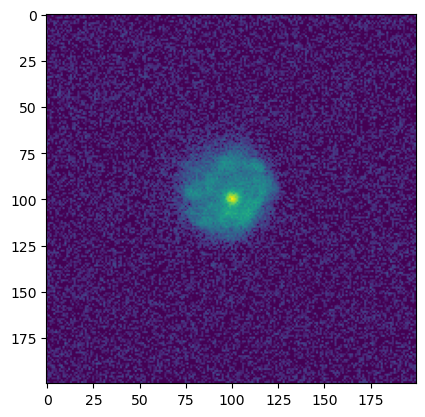

In [12]:
noise_map_full = get_noise_image(observed_img, 0, exp_time)
plt.imshow(noise_map_full)